<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Testing for Unphysical Precipitation Values in UKCP Local
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>In the set of extreme events extracted from UKCP Local (bias-corrected, 
  5km data), some events have maximum precipitation values which are 
  unphysical — i.e., higher than is physically plausible.</p>

  <p><strong>This script tests:</strong></p>
  <ul>
    <li>The number of events per catchment, per ensemble member with an unphysical value</li>
    <li>The number of pixels affected per event</li>
  </ul>

  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>130mm/hr</strong> — based on the max value in the non-bc data
  </div>

</div>

In [63]:
import numpy as np
import pandas as pd
import time
import os
import sys
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import Counter
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import importlib
import ast

import Functions_HighValsCheck
importlib.reload(Functions_HighValsCheck)

from Functions_HighValsCheck import (find_problematic_catchment_em_combos_complex, check_extremes_across_combos,
                                    plot_surrounding_ts_new, plot_n_peaks, compare_bc_nonbc_timeseries)

# ── Config ────────────────────────────────────────────────────────────────────
from config import RAINFALL_CSV_DIR, CATCHMENT_LOOKUP_DICT, OUT_DIR, CATCHMENTS, ENSEMBLE_MEMBERS 

# ── Define which catchments to run ────────────────────────────────────────────────────────────────────
all_catchments = set(CATCHMENT_LOOKUP_DICT.keys())

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Find catchment, ensemble member combinations with values >150mm/hr </h3>

  <p>For each catchment–ensemble member combination:</p>
  <ul>
    <li>Find the number of events exceeding the <strong>130mm/hr</strong> threshold</li>
    <li>Calculate this as a proportion of the total number of events</li>
  </ul>
    
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that for affected catchments the number of events affected are not insignificant: of the 66 instances of a catchment/ensemble member combination which appear in results_df ~50% have more than 10% of the events with unphysical values, and some have up to almost 50%.    
  </div>    

  <p>Also finds, for the highest peak value in each catchment:</p>
  <ul>
    <li>The number of timesteps which are unphysical (in any catchment cell) </li>
    <li>The number of cells which experience any unphysical values within 10 timesteps of the highest unphysical value </li>
    <li>The total number of cells in any cell, at any timestep (within 10 timesteps of the highest unphysical value) which are unphysical </li>     
      <li> The maximum number of cells experiencing an unphysical value concurrently </li>
      <li> The maximum number of timesteps for one cell which experience an unphysical value
  </ul>
<div style="background-color: white; border-left: 4px solid orange; 
padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that the unphysical values do not always occur in isolation. There are frequently either (i) other grid cells nearby affected, or (ii) other timesteps affected before or after.
   
  </div>   
</div>

In [64]:
if os.path.isfile("../../../Outputs/ProblematicCatchments_130Threshold.csv"):
        results_df = pd.read_csv("../../../Outputs/ProblematicCatchments_130Threshold.csv")
        problematic_catchment_nums = results_df['Catchment No.']
else:
    results_df, problematic_catchment_names, problematic_catchment_nums = find_problematic_catchment_em_combos_complex(all_catchments, 130, CATCHMENTS, CATCHMENT_LOOKUP_DICT, ENSEMBLE_MEMBERS, RAINFALL_CSV_DIR)
    results_df.to_csv("../../../Outputs/ProblematicCatchments_130Threshold.csv")
# results_df.sort_values(by='% Problematic', ascending = False)[:5]

In [65]:
# Get list of catchment_num, ensemble_member combos
problematic_combos  =[]
for num, row in results_df.iterrows():
    problematic_combos.append((row['Catchment No.'], row['Ensemble Member']))

In [66]:
# Check number of problematic events
lengths = 0
for row in results_df["Problematic Event Nums"]:
    lengths+=len(row)

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Are events with unphysical values only selected because of that unphysical value, or would they have been selected anyway? </h3>

  <p>For each catchment–ensemble member combination:</p>
  <ul>
    <li>Compare bias-corrected and non-bc version of event </li>
    <li>Check whether an extreme value is still present in non-bc event</li>
  </ul>
    
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that: for event's with an unphysical value: in the non-bias corrected data, generally there is no extreme value present in the event. Also, the shape of the event when plotted over time seems to often be completely different. When the same testing is done for events without unphysical values: the bias corrected and non-bias-corrected data are similar. The peak value occurs in the same timestep and the overall temporal shape of the event remains the same.
  </div>    
</div>

WARNING: THIS IS VERY SLOW TO RUN

In [67]:
# results = check_extremes_across_combos(results_df, plot=False)
# results.to_csv("testing_130Threshold.csv", index=False)
# testing=pd.read_csv("testing.csv")

In [68]:
# np.unique(testing['em'], return_counts=True)

In [69]:
# results['peak_timestep_agrees'].value_counts(dropna=False)
# plt.hist(results['max_value_nonbc'])

For a smaller number of events make a plot comparing the event in the bias-corrected and non-bias-corrected data:
 - Y-Axis: bias corrected data
 - X-Axis: non-bias corrected data
 
NB: scale of two axes is not the same (in order to check whether if shape, if not scale, are the same

In [70]:
# catchment_num  = combo_row['Catchment No.'][24]
# catchment_name = CATCHMENT_LOOKUP_DICT[str(catchment_num)]

 Catchment number: 3, EM: 04


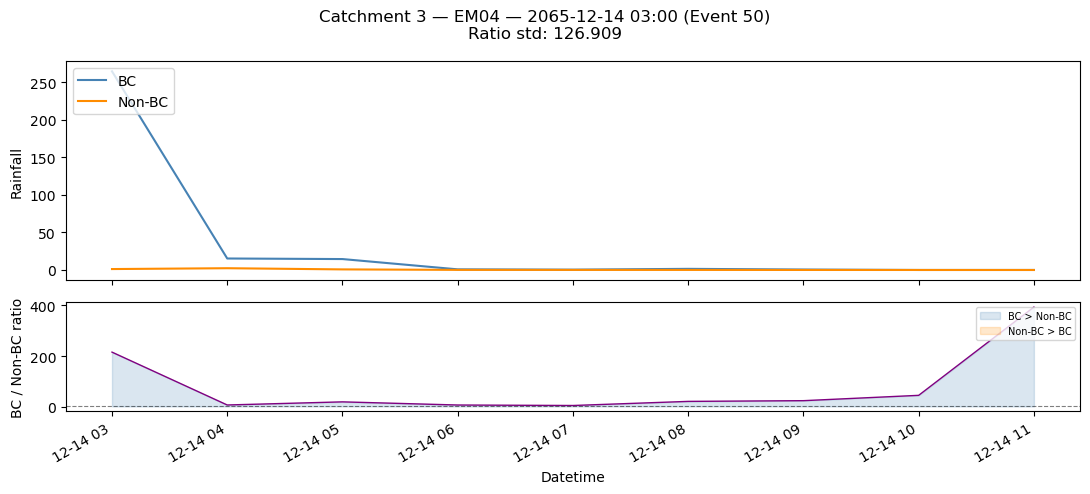

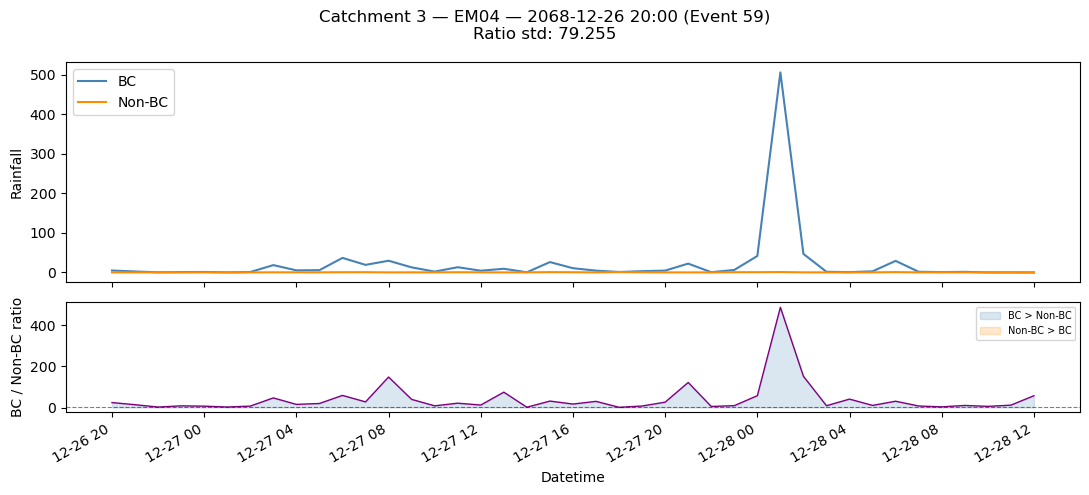

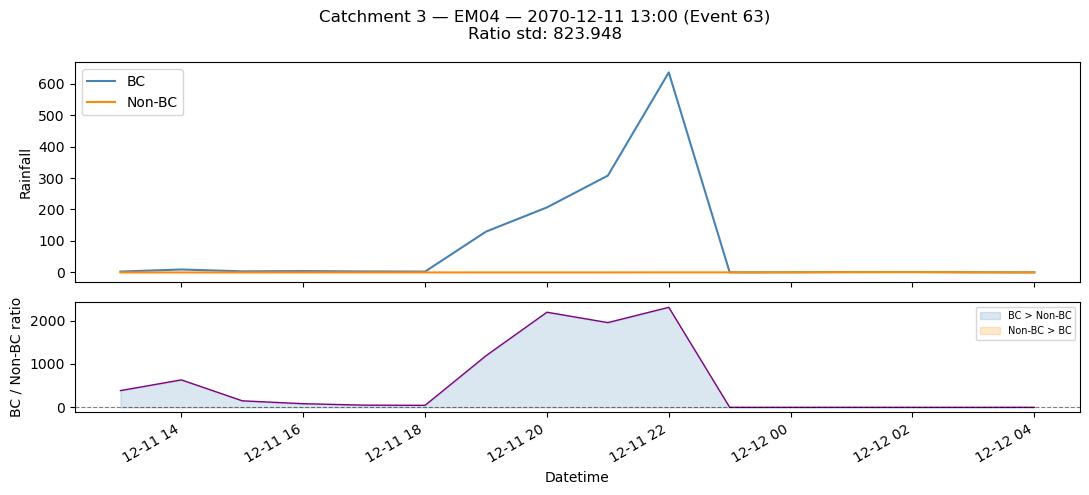

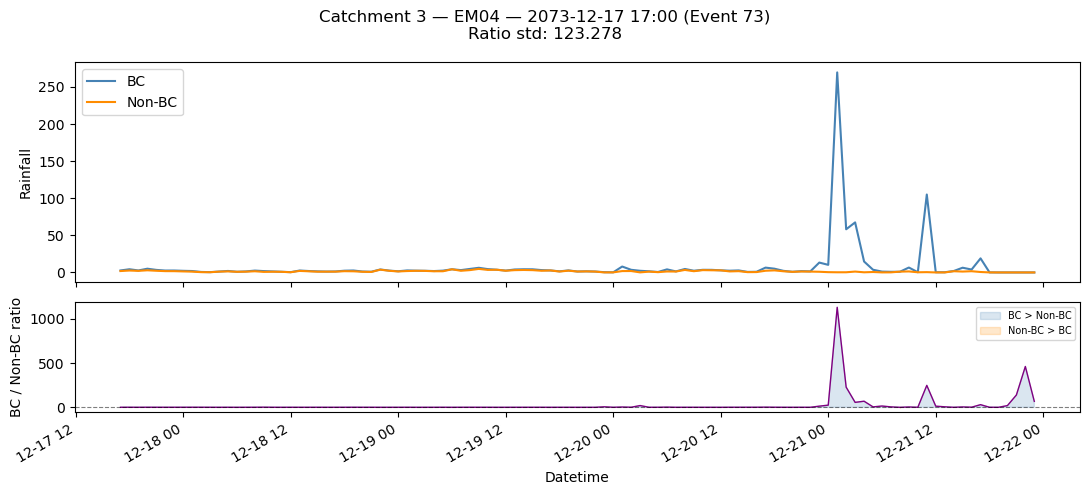

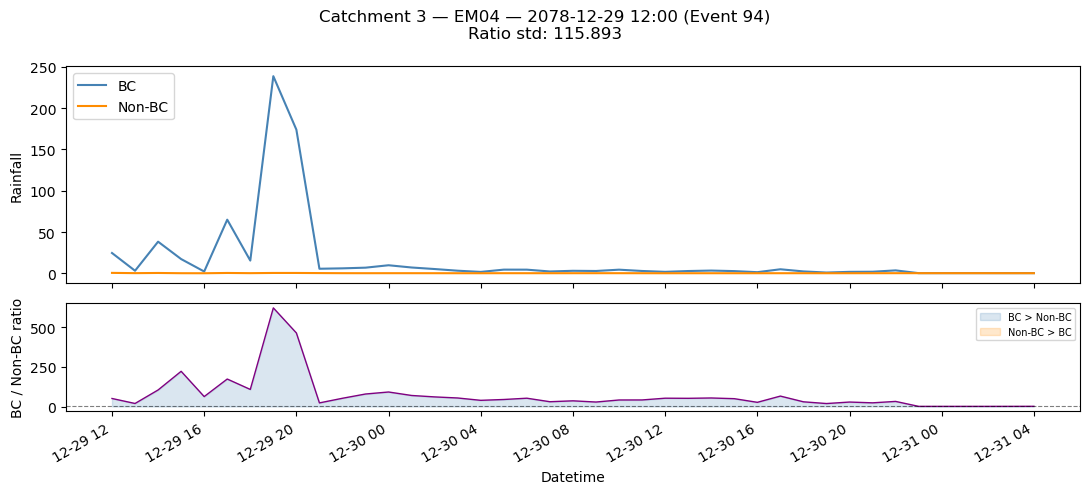

In [71]:
extremes = check_extremes_across_combos(results_df[24:25], plot=True)

---

Test the same plot for 'normal' events (e.g., no unphysical values)

---

 Catchment number: 4, EM: 01


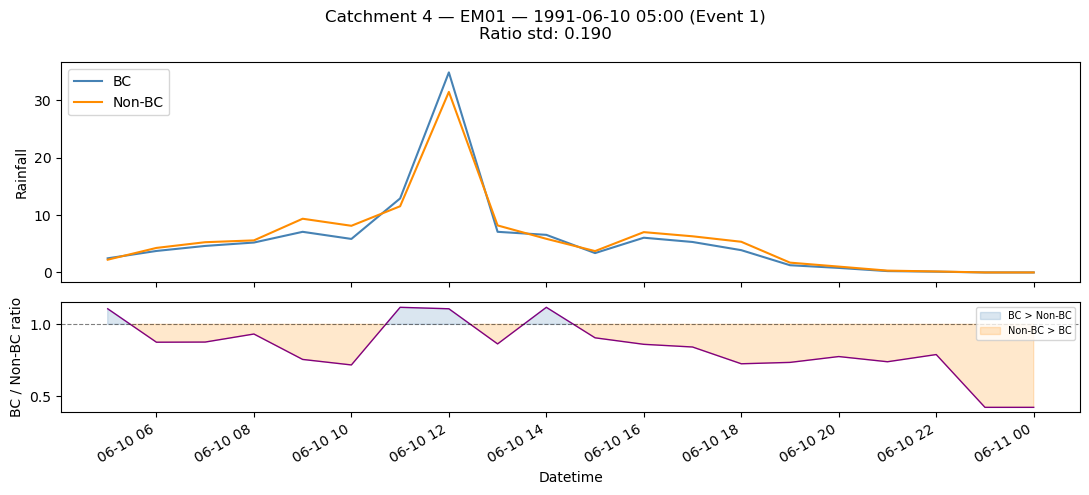

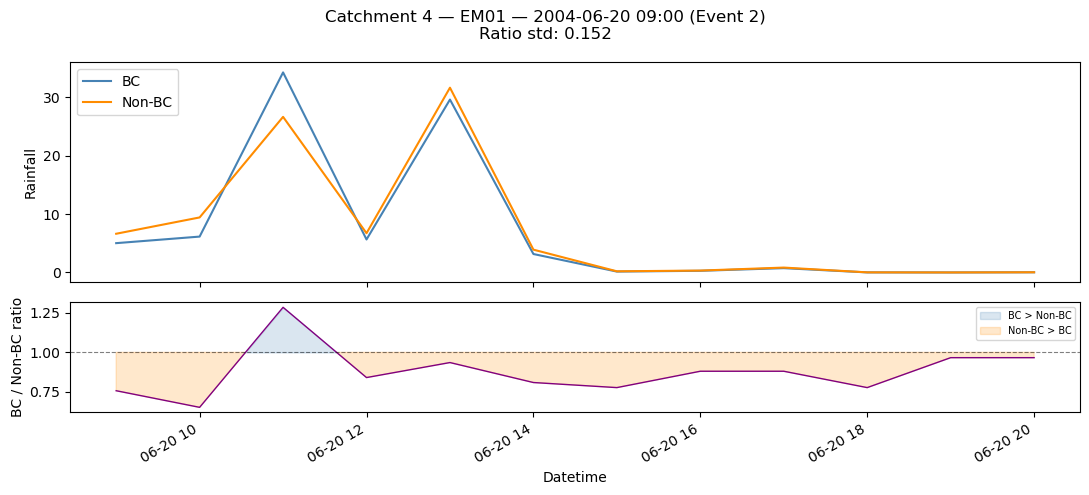

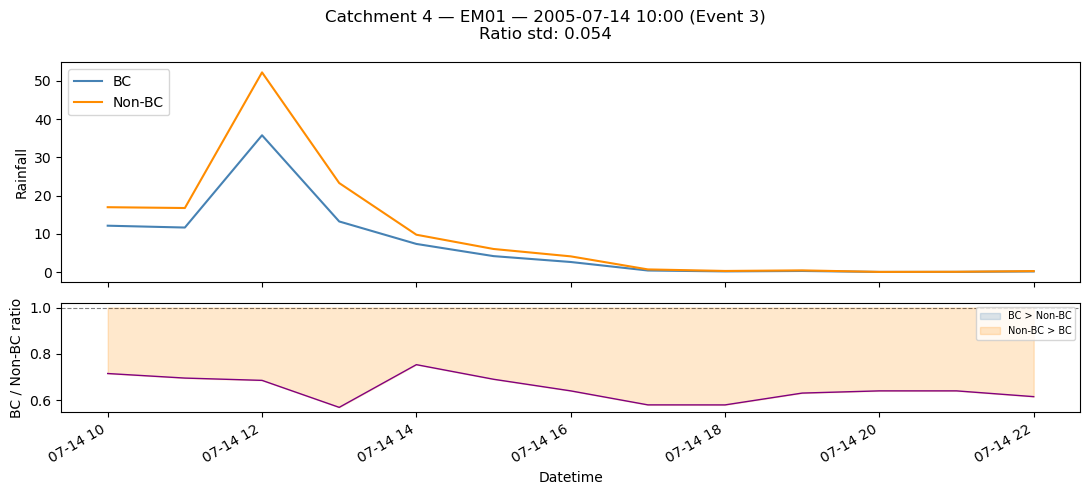

 Catchment number: 4, EM: 04


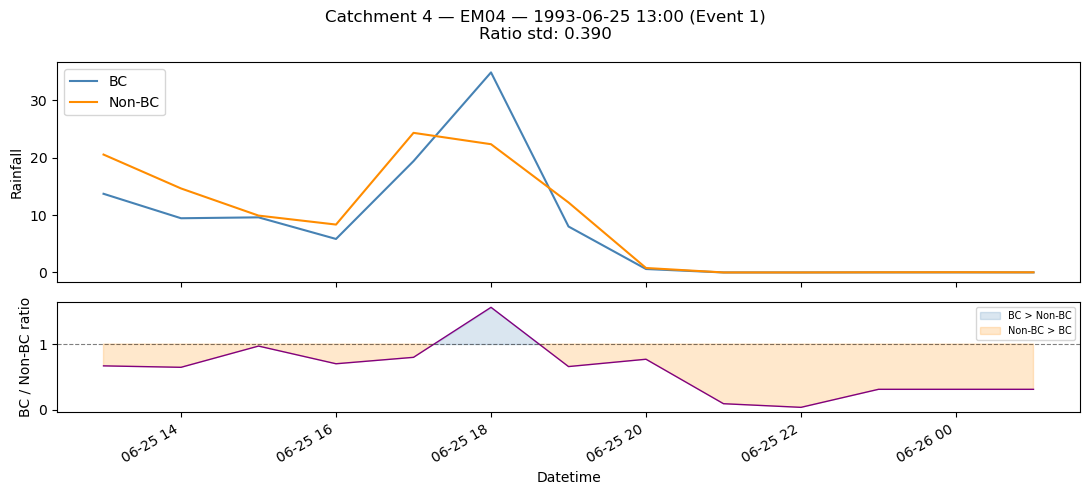

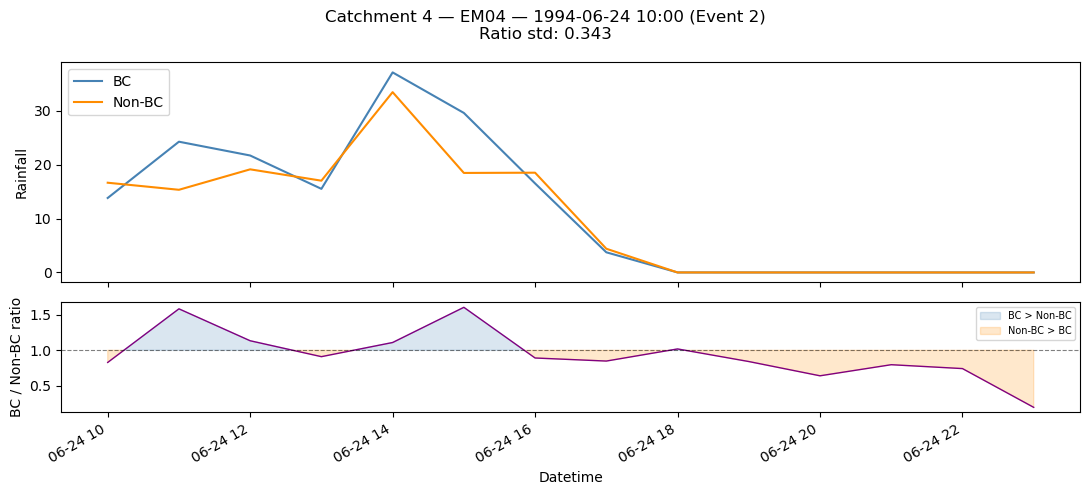

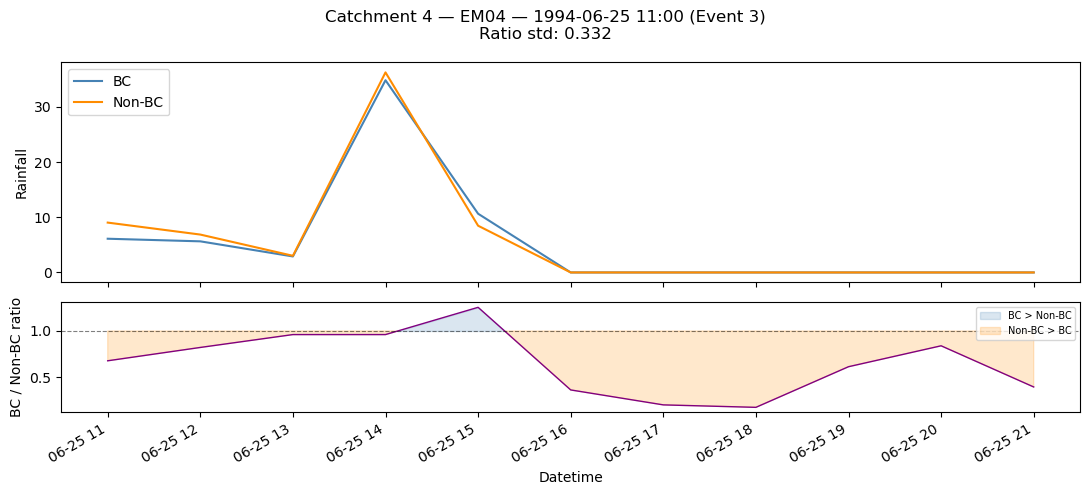

In [72]:
# Get list of catchment_num, ensemble_member combos
combos  =[]
for em in ['01', '04',]:
    combos.append(('4', em, [1,2,3]))
combos_df = pd.DataFrame(combos, columns = ['Catchment No.', 'Ensemble Member', 'Problematic Event Nums'])
results2 = check_extremes_across_combos(combos_df, plot=True)

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Check daily data corresponding to hourly events </h3>
</div>

In [73]:
results_df

,Unnamed: 0,Catchment No.,Catchment Name,Ensemble Member,Highest Peak (mm),Events > 150mm,Total Events,% Problematic,Problematic Event Nums,Timesteps w/ any exceedance,Cells w/ any exceedance,"Total (t,cell) exceedances",Max cells in 1 timestep,Max timesteps for 1 cell
0,0,104,KintyreGroup,4,882.25,30,254,11.8,"[119, 120, 122, 123, 127, 134, 135, 136, 137, ...",1,6,6,6,1
1,1,104,KintyreGroup,5,271.46,18,274,6.6,"[12, 75, 133, 135, 138, 139, 141, 146, 155, 15...",1,1,1,1,1
2,2,104,KintyreGroup,7,176.23,2,134,1.5,"[73, 130]",1,1,1,1,1
3,3,104,KintyreGroup,8,271.07,8,226,3.5,"[70, 76, 101, 104, 164, 165, 212, 215]",1,1,1,1,1
4,4,104,KintyreGroup,9,339.05,10,136,7.4,"[86, 87, 90, 108, 109, 114, 119, 127, 131, 132]",2,3,4,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,73,96,Navergroup,4,156.65,2,94,2.1,"[42, 57]",1,1,1,1,1
74,74,96,Navergroup,7,7916.53,67,169,39.6,"[59, 60, 61, 65, 68, 71, 72, 75, 76, 82, 83, 8...",1,1,1,1,1
75,75,96,Navergroup,9,2732.17,18,73,24.7,"[32, 33, 35, 40, 41, 42, 49, 50, 51, 53, 57, 5...",3,1,3,1,3
76,76,96,Navergroup,15,271.81,13,119,10.9,"[50, 52, 54, 56, 59, 61, 63, 73, 80, 82, 104, ...",1,1,1,1,1


<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot location of catchments with problematic peaks </h3>

Plots a spatial plot showing affected catchments, coloured by how many EMs have problems (NB: not by the total number of events across ensemble members (maybe this'd be more useful)
</div>

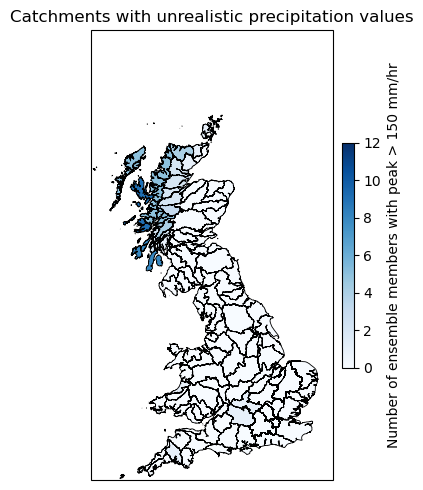

In [74]:
# Count how many ensemble members are problematic per catchment
ens_counts = Counter(problematic_catchment_nums)  # {catchment_num: count}

# Colourmap setup
max_count = len(ENSEMBLE_MEMBERS)
cmap      = cm.Blues
norm      = mcolors.Normalize(vmin=0, vmax=max_count)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': ccrs.OSGB()})

for catchment_num in CATCHMENTS['HA_NUM'].unique():
    boundary_gdf   = CATCHMENTS[CATCHMENTS['HA_NUM'] == str(catchment_num)]
    CATCHMENT_POLY = boundary_gdf.geometry.iloc[0]
    count          = ens_counts.get(catchment_num, 0)  # 0 if not problematic
    facecolor      = cmap(norm(count))
    ax.add_geometries([CATCHMENT_POLY], crs=ccrs.OSGB(), 
                      facecolor=facecolor, edgecolor='black', linewidth=0.6)

# Add colourbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Number of ensemble members with peak > 150 mm/hr', 
             shrink=0.5, pad=0.02)

ax.set_title('Catchments with unrealistic precipitation values')
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h3 style="color: black; margin: 0px;"> Testing results for one catchment: Catchment 94 (Loch Maree Group) </h3>

Two test plots: 
1. A spatial plot of the catchment for each of 9 events which for this catchment/EM combination had unphysical values
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that it’s not always the same grid cell affected in different instances of the unphysical values (although some grid cells do seem to be over represented)  </div>    
2. Plot containing both (i) Plotted timeseries including the timesteps before and after the unphysical value in the grid cell in which it happened; and (ii) Spatial plot of values across the whole catchment for the 5 timesteps both before and after the unphysical value.
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This suggests that often other unphysical values occur in the surrounding cells/timesteps to the peak. </div>    
   
**Additionally**: plot the same plots using data that hasn't been bias corrected:  

<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that the problem is introduced by the bias correction. No unphysical values are present in the non-bias corrected data at the times and locations where they appear in bias-corrected data.  </div>    

</div>

In [75]:
catchment_num = '94' #'94'
ens_num = '07'
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
print(catchment_name)
rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

LochMareegroup


In [76]:
plot_n_peaks(rainfall_cube_dir_bc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=True)

ValueError: day is out of range for month

In [ ]:
plot_surrounding_ts_new(rainfall_cube_dir_bc, catchment_num, ens_num, bc=True)

In [ ]:
plot_surrounding_ts_new(rainfall_cube_dir_notbc, catchment_num, ens_num, bc=False)

In [ ]:
# Use the rainfall events csv to extract the event from the cube

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
What happens if plot same plot using data that hasn't been bias corrected? 

</div>

In [ ]:
plot_n_peaks(rainfall_cube_dir_notbc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=False)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
Check all events for this catchment/ensemble member combination: if bias corrected data would the event still be extreme?

</div>

In [ ]:
ens_num = '08'

rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

df =compare_bc_nonbc_timeseries(rainfall_cube_dir_bc, rainfall_cube_dir_notbc, catchment_num, ens_num)
df['ratio'] = df['bc']/df['non_bc']
df

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h3 style="color: black; margin: 0px;"> Testing results for one catchment: Catchment 95 (Laxford Group) </h3>

Two test plots:  
1. A spatial plot of the catchment for each of 9 events which for this catchment/EM combination had unphysical values
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that it’s not always the same grid cell affected in different instances of the unphysical values (although some grid cells do seem to be over represented)  </div>    
2. Plot containing both (i) Plotted timeseries including the timesteps before and after the unphysical value in the grid cell in which it happened; and (ii) Spatial plot of values across the whole catchment for the 5 timesteps both before and after the unphysical value.
<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This suggests that often other unphysical values occur in the surrounding cells/timesteps to the peak. </div>    
   
**Additionally**: plot the same plots using data that hasn't been bias corrected:  

<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    This suggests that the problem is introduced by the bias correction. No unphysical values are present in the non-bias corrected data at the times and locations where they appear in bias-corrected data.  </div>    

</div>

In [ ]:
catchment_num = '95' #'94'
ens_num = '07'
catchment_name  = CATCHMENT_LOOKUP_DICT[str(catchment_num)]
print(catchment_name)

rainfall_cube_dir_bc = f"/scratch/hydro5/users/ld14116/SDM_bias_correction/Hourly/{ens_num}/"
rainfall_cube_dir_notbc = f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Precipitation/Hourly/5km/Ens_{ens_num}/"

In [ ]:
plot_n_peaks(rainfall_cube_dir_bc, ens_num = ens_num, catchment_num= catchment_num, bc=True)

In [ ]:
plot_surrounding_ts_new(rainfall_cube_dir_bc, catchment_num, ens_num, bc=True)

<div style="background-color: #e8f4f8; color: black; border-left: 4px solid steelblue; 
padding: 10px 20px; border-radius: 0px 5px 5px 0px; margin: 10px 20px;">
What happens if plot same plot using data that hasn't been bias corrected? 

</div>

In [ ]:
plot_n_peaks(rainfall_cube_dir_notbc, ens_num = ens_num, catchment_num= catchment_num, n= 9, bc=False)

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h2 style="color: black; margin: 0px;"> Use non-bc data to define cutoff threshold </h2>

  <ul>
    <li>Extract the value of each peak from across all events in the bias-corrected and non-bias-corrected data </li>
    <li> Find the maximum value in the non-bc data </li> 
    <li> Plot distribution of peak values in non-bc and bc-data:</li>      
      <ul>
    <li>Filter out events <30mm/hr for non-bias-corrected data (threshold is 30mm/hr in bc data, so need to equalise) </li>
    <li>Filter out events >150mm/hr for bias-corrected data (so that plot is readable) </li>    </ul> 
      <ul>

<div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
This shows that the maximum value in the non-bias-corrected data is 131mm/hr. The distribution of peak values is largely similar, but in the bias-corrected data there are slightly less lower values, and slightly more higher values.

   
  </div>   
</div>

In [ ]:
peaks_bc = []

for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[f"{catchment_num}"]
    try:
        for ens in ENSEMBLE_MEMBERS:
            fp = RAINFALL_CSV_DIR + f'{catchment_name}_{ens}_full_events_with_event_nums.csv'
            test = pd.read_csv(fp)['peaks']
            peaks_bc.append(test.values)
    except:
        print(f"{catchment_name} didn't work")

peaks_bc = np.concatenate(peaks_bc)

##### 
peaks_nonbc = []

for catchment_num in all_catchments:
    catchment_name = CATCHMENT_LOOKUP_DICT[f"{catchment_num}"]
    try:
        for ens in ENSEMBLE_MEMBERS:
            RAINFALL_CSV_DIR_nonbc = f'/scratch/hydro4/users/ld14116/Leanne_events/Event_tables/Fixed_threshold_10mm/{catchment_name}_Ens_{ens}_full_events.csv'
            test = pd.read_csv(RAINFALL_CSV_DIR_nonbc)['peaks']
            peaks_nonbc.append(test.values)
    except:
        print(f"{catchment_name} didn't work")

peaks_nonbc = np.concatenate(peaks_nonbc)


In [ ]:
peaks_nonbc = peaks_nonbc[peaks_nonbc>30]
peaks_bc_reasonable = peaks_bc[peaks_bc<130]

In [ ]:
plt.hist(peaks_bc_reasonable, bins=50, alpha=0.8, label='BC', density=True)
plt.hist(peaks_nonbc, bins=50, alpha=0.8, label='non-BC', density=True)

plt.legend()
plt.xlabel('Peak value')
plt.ylabel('Density')
plt.title('Distribution of peak values')
plt.show()

In [ ]:
sns.kdeplot(peaks_bc_reasonable, label='BC')
sns.kdeplot(peaks_nonbc, label='non-BC')

plt.legend()
plt.title('KDE of peak values')
plt.show()